Apps loaded: (10841, 13)
Reviews loaded: (64295, 5)
Data cleaning completed!

Top Categories:
Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


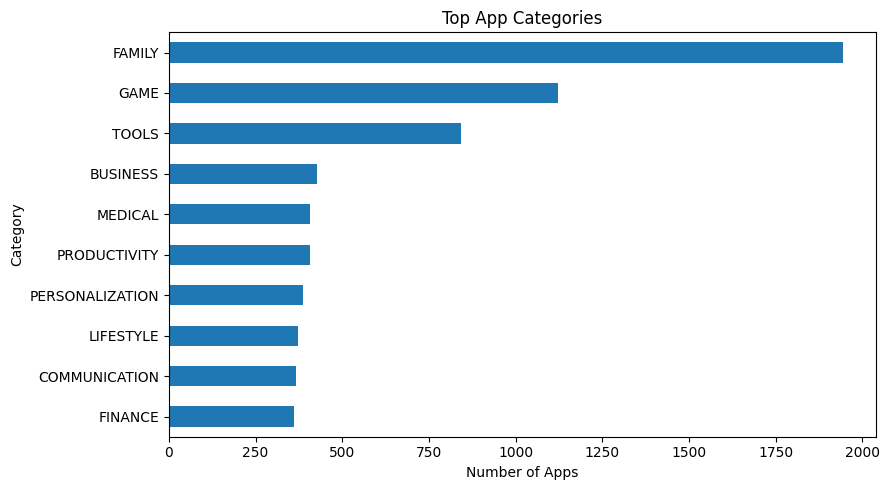


Average Rating: 4.21


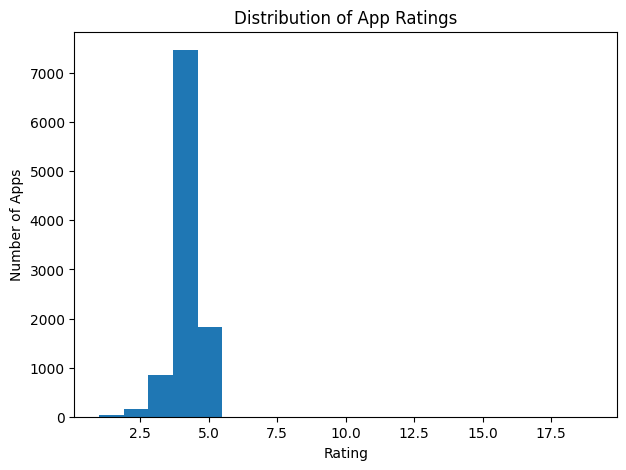


Highest Rated Categories:
Category
1.9                    19.000000
EVENTS                  4.395313
EDUCATION               4.375385
ART_AND_DESIGN          4.355385
BOOKS_AND_REFERENCE     4.336522
PERSONALIZATION         4.327062
PARENTING               4.300000
BEAUTY                  4.283019
GAME                    4.282070
HEALTH_AND_FITNESS      4.266993
Name: Rating, dtype: float64


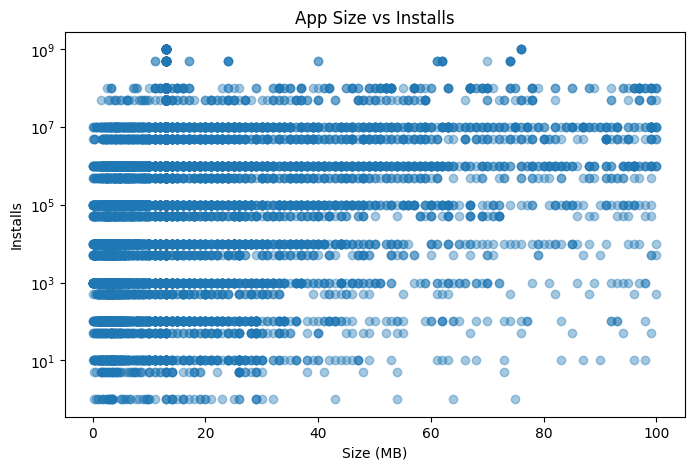

Size-Install Correlation: 0.0501

Free vs Paid:
Type
Free    9592
Paid     765
0          1
Name: count, dtype: int64


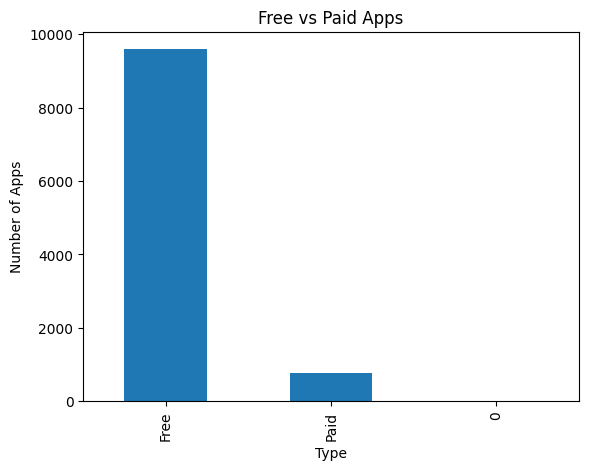


Paid Apps: 765
Average Paid App Price: 13.96

Top Revenue Categories:
Category
FAMILY             1.857803e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.942768e+06
MEDICAL            8.456536e+06
PERSONALIZATION    7.786948e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64

Sentiment Distribution:
Sentiment
Positive    22431
Neutral      8016
Negative     6980
Name: count, dtype: int64


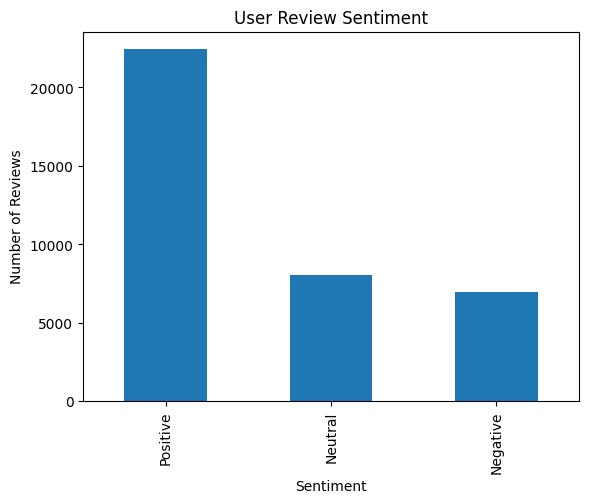


Sentiment by Category:
Sentiment            Negative  Neutral  Positive
Category                                        
ART_AND_DESIGN             52       82       248
AUTO_AND_VEHICLES          14       46       229
BEAUTY                     65       90       183
BOOKS_AND_REFERENCE       107      170       499
BUSINESS                  190      355       716
COMICS                      2        8        70
COMMUNICATION             266      389      1155
DATING                    478      568      1487
EDUCATION                  99      197       842
ENTERTAINMENT             281      308       795


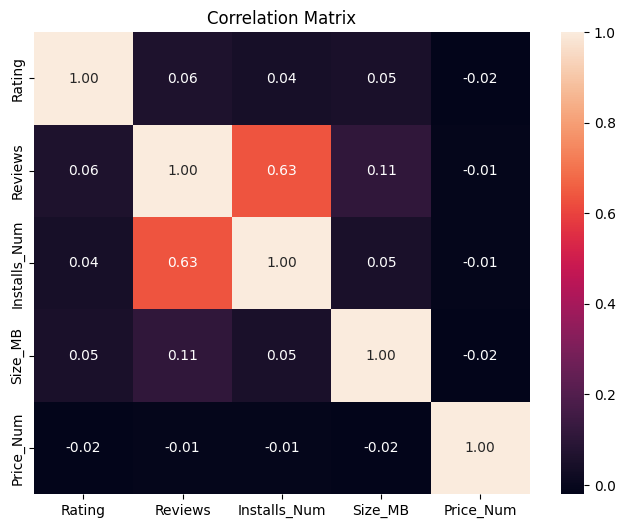


Top 10 Apps by Installs:
                            App            Category  Rating        Installs  \
2818                     Google               TOOLS     4.4  1,000,000,000+   
2256                    Google+              SOCIAL     4.2  1,000,000,000+   
2247                  Instagram              SOCIAL     4.5  1,000,000,000+   
3310                Google News  NEWS_AND_MAGAZINES     3.9  1,000,000,000+   
4939              Google Photos         PHOTOGRAPHY     4.5  1,000,000,000+   
2246                   Facebook              SOCIAL     4.1  1,000,000,000+   
2533              Google Photos         PHOTOGRAPHY     4.5  1,000,000,000+   
2722  Maps - Navigate & Explore    TRAVEL_AND_LOCAL     4.3  1,000,000,000+   
1447             Subway Surfers                GAME     4.5  1,000,000,000+   
3261    Google Play Movies & TV       VIDEO_PLAYERS     3.7  1,000,000,000+   

      Type  
2818  Free  
2256  Free  
2247  Free  
3310  Free  
4939  Free  
2246  Free  
2533  Free  


In [10]:
# ============================================================
# OASIS INFOBYTE - DATA ANALYTICS - TASK 4
# UNVEILING THE ANDROID APP MARKET
# ============================================================

!pip -q install textblob

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# 1. LOAD DATA
apps_url = "https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv"
reviews_url = "https://raw.githubusercontent.com/Shubhi550/The-Android-App-Market-on-Google-Play/master/googleplaystore_user_reviews.csv"

apps = pd.read_csv(apps_url)
reviews = pd.read_csv(reviews_url)

print("Apps loaded:", apps.shape)
print("Reviews loaded:", reviews.shape)

# 2. CLEAN APPS
apps.columns = apps.columns.str.strip()
apps = apps.drop_duplicates().reset_index(drop=True)

apps["Rating"] = pd.to_numeric(apps["Rating"], errors="coerce")
apps["Rating"] = apps["Rating"].fillna(apps["Rating"].median())

apps["Reviews"] = pd.to_numeric(
    apps["Reviews"], errors="coerce"
).fillna(0)

apps["Installs_Num"] = (
    apps["Installs"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps["Installs_Num"] = pd.to_numeric(
    apps["Installs_Num"], errors="coerce"
).fillna(0)

apps["Price_Num"] = (
    apps["Price"].astype(str)
    .str.replace("$", "", regex=False)
)

apps["Price_Num"] = pd.to_numeric(
    apps["Price_Num"], errors="coerce"
).fillna(0)

def convert_size(x):
    if pd.isna(x) or str(x) == "Varies with device":
        return np.nan
    x = str(x)
    if x.endswith("M"):
        return float(x[:-1])
    if x.endswith("k") or x.endswith("K"):
        return float(x[:-1]) / 1024
    return np.nan

apps["Size_MB"] = apps["Size"].apply(convert_size)
apps["Size_MB"] = apps["Size_MB"].fillna(apps["Size_MB"].median())

apps["Category"] = apps["Category"].fillna("Unknown")
apps["Type"] = apps["Type"].fillna("Free")

print("Data cleaning completed!")

# 3. CATEGORY ANALYSIS
category_counts = apps["Category"].value_counts()

print("\nTop Categories:")
print(category_counts.head(10))

plt.figure(figsize=(9,5))
category_counts.head(10).sort_values().plot(kind="barh")
plt.title("Top App Categories")
plt.xlabel("Number of Apps")
plt.tight_layout()
plt.show()

# 4. RATING ANALYSIS
print("\nAverage Rating:", round(apps["Rating"].mean(), 2))

plt.figure(figsize=(7,5))
plt.hist(apps["Rating"], bins=20)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

# 5. AVERAGE RATING BY CATEGORY
category_rating = apps.groupby("Category")["Rating"].mean()
print("\nHighest Rated Categories:")
print(category_rating.sort_values(ascending=False).head(10))

# 6. SIZE VS INSTALLS
data = apps[["Size_MB","Installs_Num"]].dropna()
data = data[data["Installs_Num"] > 0]

plt.figure(figsize=(8,5))
plt.scatter(data["Size_MB"], data["Installs_Num"], alpha=0.4)
plt.yscale("log")
plt.title("App Size vs Installs")
plt.xlabel("Size (MB)")
plt.ylabel("Installs")
plt.show()

print("Size-Install Correlation:",
      round(data["Size_MB"].corr(data["Installs_Num"]), 4))

# 7. FREE VS PAID
print("\nFree vs Paid:")
print(apps["Type"].value_counts())

apps["Type"].value_counts().plot(kind="bar")
plt.title("Free vs Paid Apps")
plt.ylabel("Number of Apps")
plt.show()

# 8. PAID APP ANALYSIS
paid = apps[apps["Price_Num"] > 0].copy()

print("\nPaid Apps:", len(paid))
print("Average Paid App Price:",
      round(paid["Price_Num"].mean(), 2))

paid["Estimated_Revenue"] = (
    paid["Price_Num"] * paid["Installs_Num"]
)

revenue = (
    paid.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop Revenue Categories:")
print(revenue.head(10))

# 9. USER REVIEWS & SENTIMENT
reviews.columns = reviews.columns.str.strip()

reviews_clean = reviews[
    ["App", "Translated_Review"]
].dropna().copy()

def sentiment(x):
    p = TextBlob(str(x)).sentiment.polarity
    if p > 0.05:
        return "Positive"
    elif p < -0.05:
        return "Negative"
    return "Neutral"

reviews_clean["Sentiment"] = (
    reviews_clean["Translated_Review"].apply(sentiment)
)

reviews_clean["Polarity"] = (
    reviews_clean["Translated_Review"]
    .apply(lambda x: TextBlob(str(x)).sentiment.polarity)
)

print("\nSentiment Distribution:")
print(reviews_clean["Sentiment"].value_counts())

reviews_clean["Sentiment"].value_counts().plot(kind="bar")
plt.title("User Review Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# 10. SENTIMENT BY CATEGORY
review_category = reviews_clean.merge(
    apps[["App","Category"]],
    on="App",
    how="inner"
)

sentiment_category = pd.crosstab(
    review_category["Category"],
    review_category["Sentiment"]
)

print("\nSentiment by Category:")
print(sentiment_category.head(10))

# 11. CORRELATION
cols = [
    "Rating",
    "Reviews",
    "Installs_Num",
    "Size_MB",
    "Price_Num"
]

plt.figure(figsize=(8,6))
sns.heatmap(
    apps[cols].corr(),
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

# 12. TOP APPS
print("\nTop 10 Apps by Installs:")
print(
    apps.sort_values("Installs_Num", ascending=False)
    [["App","Category","Rating","Installs","Type"]]
    .head(10)
)

print("\nTop 10 Most Reviewed Apps:")
print(
    apps.sort_values("Reviews", ascending=False)
    [["App","Category","Rating","Reviews","Installs"]]
    .head(10)
)

# 13. BUSINESS INSIGHTS
print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("• Highly represented categories have strong competition.")
print("• Maintaining high ratings improves user trust.")
print("• Free apps dominate the marketplace.")
print("• Smaller apps may improve accessibility and downloads.")
print("• Negative reviews can identify bugs and user problems.")
print("• Freemium models can be considered for monetisation.")

# 14. SAVE CLEANED DATA
apps.to_csv(
    "OIBSIP_Task4_Android_App_Market_Cleaned.csv",
    index=False
)

reviews_clean.to_csv(
    "OIBSIP_Task4_User_Reviews_Sentiment.csv",
    index=False
)

print("\n" + "="*60)
print("TASK 4 COMPLETED SUCCESSFULLY! ✅")
print("="*60)
print("Apps file saved successfully!")
print("Reviews file saved successfully!")

In [11]:
from google.colab import files

files.download("OIBSIP_Task4_Android_App_Market_Cleaned.csv")
files.download("OIBSIP_Task4_User_Reviews_Sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>